<a href="https://colab.research.google.com/github/edwardoughton/Agentic-GeoAI/blob/main/02_01_ggs662_agentic_geoai_problem_formulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 Agentic GeoAI

This week we will move from formulating research questions to defensible analysis within the context of Agentic GeoAI. 

A coding agent can produce a plausible analysis quickly. For example, when considering a risk analysis topic, I would not yet want an agent to operate without a human-in-the-loop defining what we mean by "hazard", "exposure", "vulnerability", and "risk". By this, I mean outlining what the agent should be doing and checking what the agent produces (e.g., before showing to someone else). 

This week we use a dataset we recently collected for US data centers (credit: Avi Angirekula) and relate this to natural hazard exposure. To do so, we will formulate a small multi-hazard screening task, delegate its implementation to a coding agent, and audit the result. 

The exercise is deliberately bounded to keep model token usage low (and hopefully inexpensive).

## Learning objectives

By the end of class, students should be able to:

* Translate a broad research question into an operational specification.
* Distinguish hazard, exposure, vulnerability, consequence, and risk.
* Inspect a real infrastructure dataset and define potential limitations.
* Write a bounded instruction set for a coding agent.
* Complete a workflow with a small context window (e.g., inspect, plan, act, validate).
* Test and critique an analysis produced by a geospatial agent.
* State what an exposure dataset can and cannot support.

## Recap of Week 1

Last week introduced the scope of Agentic GeoAI and we covered several important AI concepts. I hope those of you who needed it, also brushed up on your basic Python skills. 

Before we continue, I want us to recap on some of this previous content: 

* AI
* GIS
* GeoAI
* Generative AI
* Large Language Model (LLM)
* Prompt
* Agentic AI
* AI agent
* Tools (in the agentic context)
* Token
* AGENTS.md
* Agent skill
* Model Context Protocol (MCP)
* Sub-agent 
* Human-in-the-loop
* Jupyter Notebook
* Google Colab
* Code cell
* Markdown cell
* Comment
* Variable
* Assignment
* VS Code


## Class structure

1. Why problem formulation matters
2. Hazard, exposure, vulnerability, and risk
3. Inspecting a real US data center dataset
4. Designing a transparent multi-hazard exposure screen
5. A bounded coding agent exercise
6. Independent validation and Assignment 1

## Begin with an ambiguous question

The reason we would do this is because we can often learn a lot from how not to do things. 

For example: 

> Which US data centers are most at risk from natural hazards?

This sounds reasonable, but it is not yet an executable research question I would want you to investigate. 

This is because we have not defined:

* Which hazards and scenarios are included.
* Where we would like to focus geographically (regionally? globally?).
* Whether the hazard measures are comparable.
* What constitutes exposure.
* How building vulnerability or protective measures are represented.
* Which consequences matter, from repair cost to downtime, capacity loss, or cascading disruption to other sectors.
* How missing values and uncertain coordinates are treated.
* Whether a ranking is scientifically defensible.

An agent forced to fill these gaps may produce a polished but invalid answer, and this outcome ultimately lands at our feet.

I say this because a standard AI disclosure for a typical journal now looks like this:

> The authors used generative artificial intelligence tools to assist with language editing and improving the clarity of the manuscript. The authors reviewed and edited all AI-generated output and take full responsibility for the content of the published article.

Or more substantively, this:

> The authors used Claude (Anthropic) to assist with code development and manuscript editing. All generated code and text were independently reviewed, validated, and revised by the authors, who take full responsibility for the final content.





### Exercise

We can first experiment with this ambiguity.

Working with a partner, identify at least six decisions hidden inside the research question above ("which US data centers are most at risk from natural hazards?"). 

Try classify each as one of the following:

* a scientific or domain decision (maybe including theory too)
* a data decision
* an implementation decision
* an ethical or communication decision
* other (something else)

Also, use your critical thinking skills to try think through which decisions we can safely delegate to an agent.

## Video 1: improve instructions to improve code

We can take a quick watch of this video covering prompt engineering with VS Code and Copilot:

https://www.youtube.com/watch?v=hh1nOX14TyY

Consider the specific requests we provide as well as the relevant file context, tests, and any iterative refinement. The same principles apply to Codex, Claude Code, Copilot, Gemini, etc., and similar coding agents.

Record one technique that reduces ambiguity and one that could reduce unnecessary token use.

## Some theory before we turn to an example

Today we will work on a risk analysis topic. Importantly, a hazard is not a risk

A useful conceptual structure for understanding risk is as follows:

$$\text{Risk} = f(\text{hazard},\ \text{exposure},\ \text{vulnerability},\ \text{consequence})$$

* Hazard - something with the potential to cause a negative outcome (damage, disruption, etc.).
* Exposure - when an entity is able to be negatively affected by a hazard (e.g., geographically located close by).
* Vulnerability - the degree to which an exposed entity is susceptible to damage or disruption if the hazard occurs.
* Consequence - what may happen if damage or a disruption takes place.
* Risk - the combination of the likelihood of an adverse event and the severity of its consequences.

For us to do a data center risk assessment, we need to be clear on what these terms mean in the first instance. 

### Exercise

Have a go at classifying each item as hazard, exposure, vulnerability, consequence, or contextual information:

* Peak ground acceleration
* Data center coordinates
* Backup power duration
* Expected service downtime
* Wildfire severity around a building
* Structural design standard
* Compute capacity lost
* Coordinate-confidence tier



## The source repository

We will use our public [US Data Center Dataset](https://github.com/aviangirekula/datacenter-dataset) collected at GMU via the ASSIP program over summer 2026. It contains 2,696 facilities across the contiguous United States (CONUS) with explicit provenance and coordinates.

The repo documentation makes an important distinction. For example, the attached natural hazard values describe exposure, not risk. 

We use a commit pinned CSV so everyone analyzes the same snapshot. The lesson downloads it once, selects a small teaching subset, and gives only that subset to the agent.

## Data provenance and limitations to read first

Before using the values, note the repository's documented cautions:

* Facilities are represented by point coordinates, and point sampling is not always equivalent to footprint exposure.
* Coordinate precision and verification status vary.
* Wildfire codes 1–5 are ordinal severity, while codes 6 and 7 are nominal non-burnable/water classes and must not be averaged as severity.
* Wildfire conditions around a developed site may be more informative than the pixel underneath the building.
* Lightning is a coarse regional climatology, not a measurement at the building level.

Source documentation: https://github.com/aviangirekula/datacenter-dataset/blob/main/docs/hazard_exposure.md

## Load the data

The file is about a few megabytes, so downloading it once is inexpensive. If the download fails in a restricted environment, download `hazard_exposure.csv` manually from the repository and place it in `week2_datacenter_task/data/`.

In [9]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path("week2_datacenter_task")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COMMIT = "2d958975147b72dc4c04e797d4ec594a6b35c131"
DATA_URL = (
    "https://raw.githubusercontent.com/aviangirekula/datacenter-dataset/"
    f"{COMMIT}/data/processed/hazard_exposure.csv"
)
SOURCE_PATH = DATA_DIR / "hazard_exposure_source.csv"

if not SOURCE_PATH.exists():
    source_df = pd.read_csv(DATA_URL)
    source_df.to_csv(SOURCE_PATH, index=False)
else:
    source_df = pd.read_csv(SOURCE_PATH)

print(f"Rows: {len(source_df):,}")
print(f"Columns: {len(source_df.columns)}")
print(f"Pinned source commit: {COMMIT}")

Rows: 2,696
Columns: 39
Pinned source commit: 2d958975147b72dc4c04e797d4ec594a6b35c131


## Inspect before analyzing

Inspection is part of analysis, not administrative overhead. We need to understand the unit of observation, fields, missingness, and measurement scales before specifying an agent task.

In [10]:
key_columns = [
    "facility_id", "name", "facility_type", "state", "county", "latitude", "longitude",
    "coordinate_precision", "coord_confidence",
    "haz_lightning_flash_per_km2_yr",
    "haz_seismic_pga_g_2475yr_usgs",
    "haz_wildfire_burnable_frac_2400m",
    "haz_wildfire_max_severity_2400m",
]

missing_columns = sorted(set(key_columns) - set(source_df.columns))
assert not missing_columns, f"Source schema changed; missing: {missing_columns}"
display(source_df[key_columns].head())
display(source_df[key_columns].isna().mean().sort_values(ascending=False).rename("missing_share"))
print("Unique facility IDs:", source_df.facility_id.is_unique)

,facility_id,name,facility_type,state,county,latitude,longitude,coordinate_precision,coord_confidence,haz_lightning_flash_per_km2_yr,haz_seismic_pga_g_2475yr_usgs,haz_wildfire_burnable_frac_2400m,haz_wildfire_max_severity_2400m
0,dc_9bb24f423687,CoreSite DC1,colocation,DC,District of Columbia,38.902580,-77.029211,building,medium,13.629329,0.076,0.048387,2.0
1,dc_a6e2e1513613,Southwest Cyberport,unknown,NM,Bernalillo,35.101960,-106.589330,building,medium,9.913078,0.170,0.012048,2.0
2,dc_a686ad9e9a88,NocRoom Miami IT Services,unknown,FL,Miami-Dade,25.791545,-80.317748,building,medium,22.965288,0.022,0.060000,3.0
3,dc_6d263b15b250,NocRoom Miami IT Services,unknown,FL,Miami-Dade,25.776033,-80.193092,building,medium,22.965288,0.021,0.024194,3.0
4,dc_880a171377bb,Center for Computation & Technology (CCT),unknown,LA,East Baton Rouge,30.407446,-91.172545,building,medium,27.227249,0.054,0.247967,1.0


name                                0.081231
haz_wildfire_max_severity_2400m     0.003338
facility_id                         0.000000
state                               0.000000
facility_type                       0.000000
county                              0.000000
latitude                            0.000000
coordinate_precision                0.000000
longitude                           0.000000
coord_confidence                    0.000000
haz_lightning_flash_per_km2_yr      0.000000
haz_seismic_pga_g_2475yr_usgs       0.000000
haz_wildfire_burnable_frac_2400m    0.000000
Name: missing_share, dtype: float64

Unique facility IDs: True


### Exercise: data audit

Answer before continuing:

* What does one row represent?
* Which columns contain location, hazard, and data-quality information?
* Which wildfire field is ordinal and appropriate for ranking?
* Why might a 2.4 km surrounding-area measure be preferable to the facility's underlying pixel?
* Which variables needed for risk are absent?
* What should happen when a hazard value is missing: zero, deletion, imputation, or an explicit unknown?

## Create a small teaching subset

Sending the full source table and its provenance fields to an agent would consume unnecessary context. We first filter explicitly to **Loudoun County, Virginia**, using the source dataset's `county` field. We then create a compact subset containing:

* Loudoun facilities with the highest local values for each of three hazard measures; and
* a deterministic background sample.

This is a **teaching sample, not a representative sample of Loudoun County or the United States**. It supports workflow testing and local comparison, but not prevalence estimates.

In [11]:
analysis_columns = [
    "facility_id", "name", "facility_type", "state", "county", "latitude", "longitude",
    "coordinate_precision", "coord_confidence",
    "haz_lightning_flash_per_km2_yr",
    "haz_seismic_pga_g_2475yr_usgs",
    "haz_wildfire_burnable_frac_2400m",
    "haz_wildfire_max_severity_2400m",
]

clean = source_df[analysis_columns].copy()
numeric_columns = [
    "latitude", "longitude", "haz_lightning_flash_per_km2_yr",
    "haz_seismic_pga_g_2475yr_usgs", "haz_wildfire_burnable_frac_2400m",
    "haz_wildfire_max_severity_2400m",
]
for column in numeric_columns:
    clean[column] = pd.to_numeric(clean[column], errors="coerce")

complete = clean.dropna(subset=numeric_columns).copy()
loudoun = complete.loc[
    complete["state"].eq("VA") & complete["county"].str.strip().eq("Loudoun")
].copy()
assert not loudoun.empty, "No complete Loudoun County records found"
hazard_columns = [
    "haz_lightning_flash_per_km2_yr",
    "haz_seismic_pga_g_2475yr_usgs",
    "haz_wildfire_max_severity_2400m",
]

selected_ids = set()
for column in hazard_columns:
    selected_ids.update(loudoun.nlargest(10, column).facility_id)

remaining = loudoun.loc[~loudoun.facility_id.isin(selected_ids)]
background_ids = set(remaining.sample(n=min(30, len(remaining)), random_state=42).facility_id)
subset = loudoun.loc[loudoun.facility_id.isin(selected_ids | background_ids)].copy()
subset = subset.sort_values("facility_id").reset_index(drop=True)

SUBSET_PATH = DATA_DIR / "datacenter_exposure_subset.csv"
subset.to_csv(SUBSET_PATH, index=False)

assert subset.facility_id.is_unique
assert (subset["county"] == "Loudoun").all()
assert "dc_9351a2fe0177" in set(subset.facility_id), "Known validation case missing"
print(f"Complete Loudoun County rows: {len(loudoun):,}")
print(f"Teaching-subset rows: {len(subset)}")
print(f"Saved: {SUBSET_PATH}")

Complete Loudoun County rows: 247
Teaching-subset rows: 59
Saved: week2_datacenter_task\data\datacenter_exposure_subset.csv


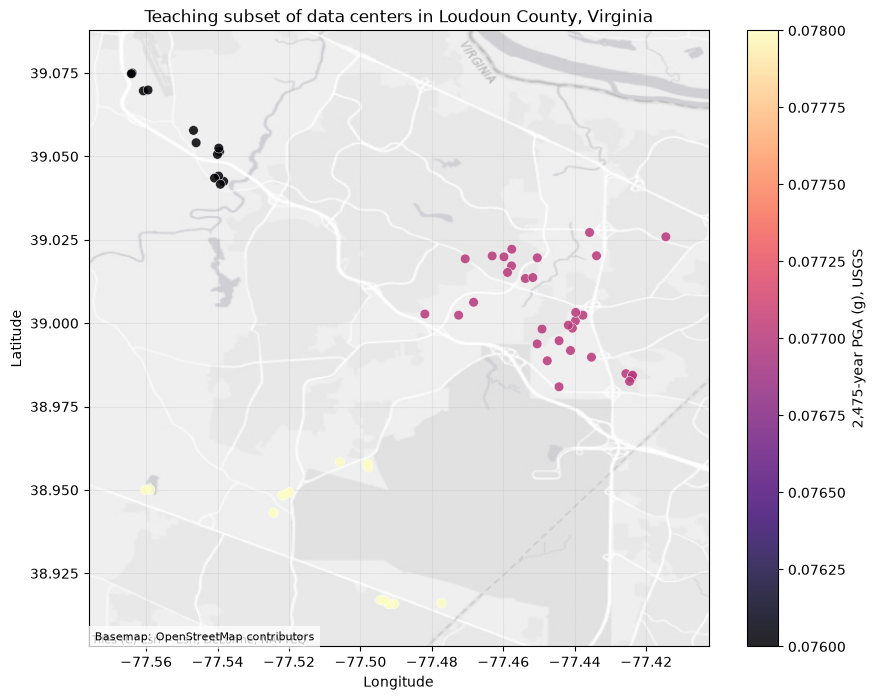

In [19]:
import matplotlib.pyplot as plt
import contextily as cx

fig, ax = plt.subplots(figsize=(10, 8))
points = ax.scatter(
    subset.longitude, subset.latitude,
    c=subset.haz_seismic_pga_g_2475yr_usgs,
    cmap="magma", s=48, alpha=0.85, edgecolor="white", linewidth=0.4, zorder=2,
)
fig.colorbar(points, ax=ax, label="2,475-year PGA (g), USGS")
ax.set(
    xlabel="Longitude", ylabel="Latitude",
    title="Teaching subset of data centers in Loudoun County, Virginia",
)
ax.margins(0.08)
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.Esri.WorldGrayCanvas)
ax.grid(alpha=0.2)
ax.text(0.01, 0.01, "Basemap: OpenStreetMap contributors", transform=ax.transAxes, fontsize=8,
        bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none"})
plt.show()


### Exercise: interpret the preview carefully

* Does this map show hazard, exposure, vulnerability, or risk?
* Why must we not infer the countywide or national distribution of exposure from this sample?
* What does marker density partly reflect?
* What context does the basemap add, and what analytical information does it still not provide?
* Would connecting the points with lines have any analytical meaning?

## Operationalize a transparent screening rule

For this lesson only, we define three binary flags:

| Flag | Teaching threshold |
|---|---:|
| Seismic exposure | USGS 2,475-year PGA ≥ 0.078 g |
| Lightning exposure | ≥ 13.62 flashes per km² per year |
| Wildfire exposure | maximum ordinal severity within 2.4 km ≥ 2 |

The exposure count is the sum of the three flags. We label 0 as `lower`, 1 as `moderate`, and 2–3 as `elevated` screening priority.

These thresholds were chosen to reveal variation within the observed Loudoun records. They are transparent teaching choices, not validated damage thresholds or engineering safety standards. 

The three indicators also have different units and resolutions. The resulting category is an exposure screen, not a probability of failure, expected loss, or risk score.

### Exercise

Discuss:

* What information is lost by converting continuous values into binary flags?
* Is adding three flags equivalent to assuming equal importance?
* Can a count of unlike hazards be called a risk score?
* How would coordinate uncertainty affect the wildfire classification?
* Should missing data produce a zero or an unknown classification?
* What alternative formulation would you prefer, and why?

## Establish an independent known case

The national thresholds used previously produce no variation in Loudoun County: all 247 complete facilities receive zero flags. For this local teaching exercise we therefore use **comparison thresholds within the observed Loudoun data**. These are not engineering safety standards or evidence of dangerous exposure.

Before involving the agent, manually inspect one facility. For `dc_9351a2fe0177`:

* seismic PGA is at least 0.078 g → 1;
* lightning is at least 13.62 flashes/km²/year → 1;
* maximum wildfire severity within 2.4 km is below 2 → 0.

The expected exposure count is therefore 2, with an `elevated` screening category. This becomes a small test oracle.

In [13]:
known = subset.loc[subset.facility_id == "dc_9351a2fe0177"].iloc[0]
display(known[hazard_columns])
known_count = int(known.haz_seismic_pga_g_2475yr_usgs >= 0.078)
known_count += int(known.haz_lightning_flash_per_km2_yr >= 13.62)
known_count += int(known.haz_wildfire_max_severity_2400m >= 2.0)
assert known_count == 2
print("Independent expected exposure count:", known_count)

haz_lightning_flash_per_km2_yr     13.629329
haz_seismic_pga_g_2475yr_usgs          0.078
haz_wildfire_max_severity_2400m          1.0
Name: 38, dtype: object

Independent expected exposure count: 2


## A specification before a prompt

An agent specification should define:

| Element | Decision in this exercise |
|---|---|
| Objective | Produce a transparent multi-hazard exposure screen |
| Unit of analysis | One data center |
| Scope | Small, hazard-enriched teaching subset of Loudoun County facilities |
| Inputs | One local CSV with specified fields |
| Operations | Three fixed threshold flags and their sum |
| Missing values | Mark incomplete; never replace with zero |
| Outputs | Facility results, county summary, basemap, text summary |
| Validation | Schema, IDs, row count, ranges, and known case |
| Stopping condition | All required files exist and checks pass |
| Claim boundary | Exposure screening only; no risk or loss claim |

## Responsible review of AI-generated code

We can watch this video focusing on reviewing and refining suggestions:

https://www.youtube.com/watch?v=n0NlxUyA7FI

While watching, consider what evidence would convince you that an agent-generated infrastructure analysis is correct. 

## Lightweight agent protocol

Run the notebook locally from the cloned repository in VS Code so your coding agent can access `week2_datacenter_task`.

**Token and cost boundaries**

* Use a standard or economical coding mode; advanced reasoning is unnecessary.
* Give the agent only `datacenter_exposure_subset.csv` and the instruction below.
* Do not give it the full source repository or the 2 MB source CSV.
* Disable web search and request no additional datasets.
* Use one main instruction and at most one targeted repair instruction.
* Ask for concise output and no tutorial-style explanation.
* Do not run multiple agents on the same task.

The workflow remains agentic: the agent inspects, plans, edits, executes, observes checks, and stops at explicit acceptance criteria.

## Main agent instruction

Copy this into your coding agent:

> Work only inside `week2_datacenter_task`. Inspect `data/datacenter_exposure_subset.csv`, then give a plan of no more than five bullets and implement it without waiting for confirmation. Create `exposure_analysis.py` using pandas, matplotlib, and contextily. Confirm every input row is in Loudoun County, Virginia. For each facility, create three Boolean local-comparison flags: `seismic_high` where `haz_seismic_pga_g_2475yr_usgs >= 0.078`; `lightning_high` where `haz_lightning_flash_per_km2_yr >= 13.62`; and `wildfire_high` where `haz_wildfire_max_severity_2400m >= 2.0`. State that these teaching thresholds distinguish local variation and are not engineering safety standards. Never replace missing hazard values with zero: set `data_complete=False` and leave the count and category missing for incomplete rows. For complete rows, calculate `exposure_count` as the sum of the flags and assign `screening_category` as `lower` for 0, `moderate` for 1, and `elevated` for 2 or 3. Create `outputs/facility_exposure_screen.csv`, `outputs/county_summary.csv`, `outputs/exposure_map.png`, and `outputs/summary.txt`. The map must use longitude and latitude, show category with a legend, add an OpenStreetMap basemap with attribution using contextily, and state that this is a hazard-enriched Loudoun teaching sample. The summary must explicitly say that this is exposure screening, not risk or expected loss. Validate unique input IDs, unchanged row count and IDs, Loudoun County scope, coordinate ranges, flag/count agreement, valid categories, and that facility `dc_9351a2fe0177` has count 2 and category `elevated`. Run the script. Report only the files created and whether all checks passed. Do not browse for analytical information, install packages, download additional analytical data, invent vulnerability information, create a risk score, or expand the scope. Basemap tile retrieval by contextily is allowed.

### Exercise: predict and inspect

Before running the agent:

* Predict where within Loudoun the facilities carrying each individual hazard flag may cluster.
* Identify two ways the script could run successfully yet remain analytically wrong.
* Highlight every phrase in the instruction that constrains scientific meaning.
* Identify the phrases that reduce token usage.

Then run the agent and record whether the optional repair turn was needed.

## Independently audit the outputs

Return to this notebook after the agent finishes. Do not rely on its statement that checks passed.

In [14]:
RESULT_PATH = OUTPUT_DIR / "facility_exposure_screen.csv"
COUNTY_PATH = OUTPUT_DIR / "county_summary.csv"
MAP_PATH = OUTPUT_DIR / "exposure_map.png"
SUMMARY_PATH = OUTPUT_DIR / "summary.txt"

for path in [RESULT_PATH, COUNTY_PATH, MAP_PATH, SUMMARY_PATH]:
    assert path.exists(), f"Missing required output: {path}"

results = pd.read_csv(RESULT_PATH)
display(results.head())
print(SUMMARY_PATH.read_text(encoding="utf-8"))

AssertionError: Missing required output: week2_datacenter_task\outputs\facility_exposure_screen.csv

In [ ]:
required = {
    "facility_id", "seismic_high", "lightning_high", "wildfire_high",
    "data_complete", "exposure_count", "screening_category",
}
assert required.issubset(results.columns), "Required result columns are missing"
assert len(results) == len(subset), "Row count changed"
assert results.facility_id.is_unique, "Duplicate facility IDs"
assert set(results.facility_id) == set(subset.facility_id), "Facility IDs changed"

complete_results = results.loc[results.data_complete.astype(str).str.lower() == "true"].copy()
flag_sum = complete_results[["seismic_high", "lightning_high", "wildfire_high"]].astype(int).sum(axis=1)
assert (complete_results.exposure_count.astype(int) == flag_sum).all(), "Flag/count mismatch"
assert set(complete_results.screening_category).issubset({"lower", "moderate", "elevated"})

known_result = results.loc[results.facility_id == "dc_9351a2fe0177"].iloc[0]
assert int(known_result.exposure_count) == 2
assert known_result.screening_category == "elevated"
assert "not risk" in SUMMARY_PATH.read_text(encoding="utf-8").lower()
print("Independent structural, numerical, known-case, and claim-boundary checks passed.")

### Exercise: visual and conceptual audit

Open the generated map and answer:

* Are coordinates geographically plausible?
* Does the legend match the output table?
* Does the title disclose the hazard-enriched sample?
* Are missing observations visually distinguishable?
* Does the map or summary accidentally describe the category as risk?
* Can the county summary be used to estimate countywide prevalence? Why not?
* What vulnerability and consequence data would be needed for a genuine risk assessment?

If a check fails, send one concise repair request naming the observed failure and expected behavior. Do not request a rewrite.

## From exposure screening toward risk

A defensible risk model would require additional evidence, potentially including:

* hazard occurrence probabilities or scenario frequencies;
* building design, age, elevation, fire protection, and fragility relationships;
* backup power, cooling redundancy, water dependency, and network redundancy;
* compute or service capacity at each facility;
* repair cost, downtime, customers affected, and cascading dependencies;
* uncertainty and sensitivity analysis.

The responsible analytical conclusion today may be: **the current data can support exposure screening, but cannot support expected-loss or facility-risk rankings.** Recognizing that boundary is successful problem formulation.

## Assignment 1: formulate, delegate, and audit

Using the supplied teaching subset, modify **one** analytical choice:

* revise one threshold and justify it;
* analyze one hazard separately instead of combining flags;
* introduce an explicit `unknown` category for a data-quality condition; or
* compare two alternative screening formulations.

Submit:

1. `SPEC.md` (maximum 500 words): objective, unit of analysis, scope, fields, operations, missing-data rule, outputs, validation, and claim boundary.
2. Your exact initial agent instruction and, if necessary, one repair instruction.
3. The analysis script, result tables, summary, and one map.
4. At least three automated checks, including one independently calculated known case.
5. `reflection.md` (maximum 250 words): one human judgment, one agent decision audited, one limitation, and the additional evidence needed to move from exposure to risk.

**Cost boundary:** use only the supplied subset; no browsing, new datasets, parallel agents, package installation, or more than one repair turn.

## Assignment 1 marking guide

| Criterion | Weight |
|---|---:|
| Geographic problem, concepts, and claim boundary are explicit | 30% |
| Agent instruction is bounded and consistent with the specification | 20% |
| Workflow reproducibly creates the required artifacts | 20% |
| Automated and visual validation are meaningful | 20% |
| Reflection distinguishes exposure from vulnerability and risk | 10% |

Code complexity, model choice, and token consumption do not earn marks.

## Recap

Today we followed a complete but inexpensive agentic workflow:

**Ambiguous question → conceptual model → data audit → operational specification → bounded agent action → independent validation → claim audit**

The central lesson is that an agent can accelerate implementation, but the analyst remains responsible for what the variables mean, which claims the data support, and what evidence is required before an exposure screen becomes a risk assessment.